# Early replication nucleosome entropy 

Recreate and clean up the story around gene body nucleosome entropy and replication timing



In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from src.GenomeDeconvolutionAnalysis import GenomeDeconvolutionAnalysis

outdir = "output/deconvolved_genome_g0066_offset1_10k_10x10_2024_10_11/"
analysis = GenomeDeconvolutionAnalysis(outdir)


In [3]:
from src.geneset import get_deconvolved_geneset

genes = get_deconvolved_geneset()


In [80]:
# all_f, all_gb_occ = analysis.load_stacked_mnase_data_for_genes(genes, 
#     compute_gb_occ=True, padding=5000, normalize=False)


,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end,gene_index
orf_name,,,,,,,,,,,,,,,,
YHR054C,YHR054C,8,gene,213185,214249,-,Uncharacterized,1064,214249,213185,NaN,214249.0,214549.0,213749.0,214249.0,2325
YHR055C,CUP1-2,8,gene,214533,214718,-,Verified,185,214778,214359,False,214778.0,215078.0,214278.0,214778.0,2326


,gene,chr,cat,start,stop,strand,classification,length,TSS,PAS,manually_curated,promoter_start,promoter_end,gene_body_start,gene_body_end,gene_index
orf_name,,,,,,,,,,,,,,,,
YIR037W,HYR1,9,gene,423128,423619,+,Verified,491,423068,423711,False,422768.0,423068.0,423068.0,423568.0,2681
YIR038C,GTT1,9,gene,423809,424513,-,Verified,704,424544,423688,False,424544.0,424844.0,424044.0,424544.0,2682


In [163]:
from src.helpers import calc_entropy
from src.GenomeDeconvolutionAnalysis import compute_entropy_func

all_f, all_gb_entropies = analysis.load_stacked_mnase_data_for_genes(genes, 
    padding=5000, normalize=False, compute_custom_func=compute_entropy_func)


In [210]:
_, all_gb_occupancies = analysis.load_stacked_mnase_data_for_genes(genes, 
    padding=5000, normalize=False, compute_gb_occ=True)

In [5]:
# Load replication timing

# Sort the gb occ by replication timing, also compute entropy and compare the stories

# Then plot centered on the replication timing, reuse code previously written
# for centering

In [6]:
genes_replication = pd.read_csv('data/replication_timing/yl_2019/genes_replication_timing_shared.csv').set_index('orf_name')
genes_replication = genes_replication.sort_values('replication_time')

In [8]:
from src.config import load_configs_by_config_type

config, _ = load_configs_by_config_type('shared')
t_indices = config.get_Hpositions_for_branch('t')

In [213]:
all_gb_entropies_sorted_by_repl = all_gb_entropies.loc[genes_replication.index]
all_gb_occupancies_sorted_by_repl = all_gb_occupancies.loc[genes_replication.index]

In [373]:
def plot_replication_entropy_occupancies(all_gb_entropies_sorted_by_repl, 
    all_gb_occupancies_sorted_by_repl):
    
    normalized_entropies = (all_gb_entropies_sorted_by_repl - 
         all_gb_entropies_sorted_by_repl.mean(axis=1).values.reshape(-1, 1))

    normalized_occupancies = (all_gb_occupancies_sorted_by_repl - 
        all_gb_occupancies_sorted_by_repl.mean(axis=1).values.reshape(-1, 1))

    plt.figure(figsize=(6, 8))
    plt.subplot(2, 2, 1)
    plt.imshow(all_gb_entropies_sorted_by_repl[t_indices].astype(float), 
               aspect='auto', cmap='viridis')
    plt.title("Nucleosome Entropy")
    #plt.yticks([])
    #plt.xticks([])
    plt.ylabel("Genes sorted by replication")
    
    n = len(all_gb_entropies_sorted_by_repl)
    plt.subplot(2, 2, 2)
    plt.imshow(normalized_entropies[t_indices].astype(float), aspect='auto', 
        cmap='RdBu_r')
    plt.title("Normalized nucleosome Entropy")
    plt.yticks([])
    plt.xticks([])

    plt.subplot(2, 2, 3)
    plt.imshow(all_gb_occupancies_sorted_by_repl[t_indices].astype(float), aspect='auto',
        cmap='viridis')
    plt.title("Nucleosome occupancy")
    plt.yticks([])
    plt.xticks([])
    plt.ylabel("Genes sorted by replication")
    plt.xlabel("Single cell time")

    plt.subplot(2, 2, 4)
    plt.imshow(normalized_occupancies[t_indices].astype(float), aspect='auto', 
        cmap='RdBu_r')
    plt.title("Normalized occupancy")
    plt.yticks([])
    plt.xticks([])
    plt.xlabel("Single cell time")

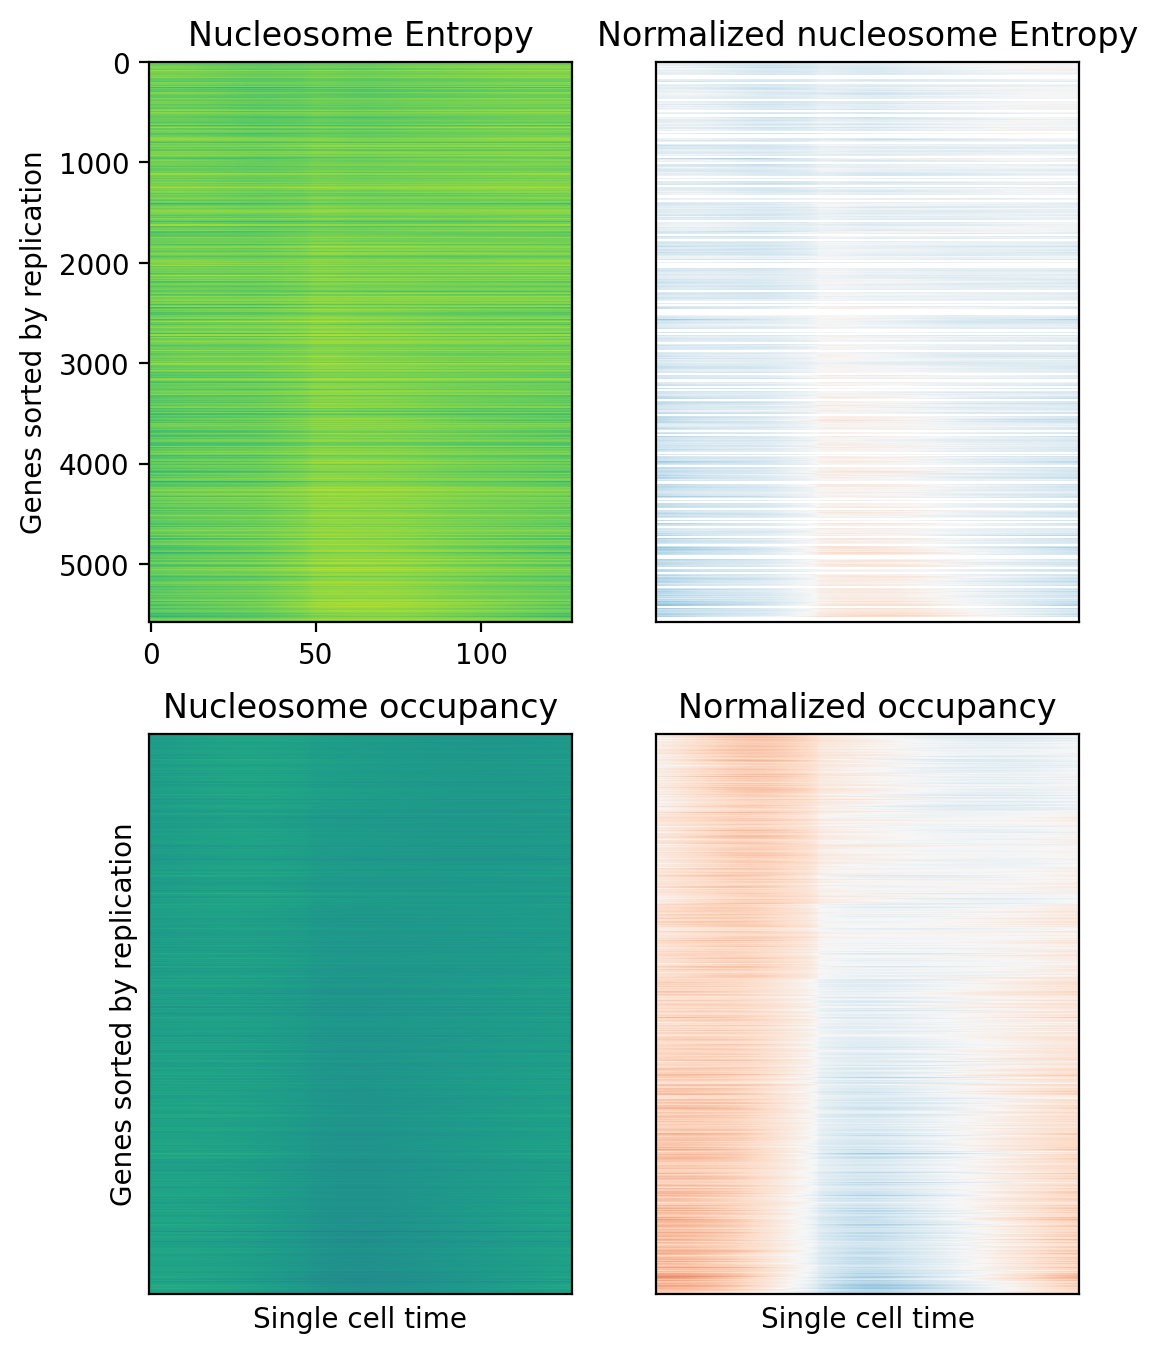

In [374]:
plot_replication_entropy_occupancies(all_gb_entropies_sorted_by_repl, 
    all_gb_occupancies_sorted_by_repl)

In [462]:
from src.helpers import select_columns_by_indices
from src.gene_chromatin_replication_analysis import convert_h_indices_to_t
from src.config import load_configs_by_config_type

def plot_raw_and_normalized_entropy(all_vals, title=None, delta_in_indices=50,
                                   h_line=None):
    """Plot heatmaps of the raw and normalized entropy data"""

    normalized_vals = (all_vals - all_vals.mean(axis=1).values.reshape(-1, 1))

    def shift_data(all_vals):
        selected_repls = genes_replication.loc[all_vals.index]
        config, _ = load_configs_by_config_type('shared')

        delta_in_min = delta_in_indices/2.
        repl_indices_t = np.array(
            convert_h_indices_to_t(config, selected_repls.replication_H_index))

        repl_indices_minus = repl_indices_t-delta_in_indices
        repl_indices_plus = repl_indices_t+delta_in_indices

        raw_window_dat = select_columns_by_indices(all_vals[t_indices], 
            repl_indices_minus, repl_indices_plus)
        n = len(all_vals)
        extent = [-delta_in_min, delta_in_min, 0, n]

        return raw_window_dat, extent

    raw_window_dat, extent = shift_data(all_vals)
    norm_window_dat, _ = shift_data(normalized_vals)
    n = len(raw_window_dat)

    plt.subplot(1, 2, 1)
    plt.imshow(raw_window_dat, cmap='viridis', 
            aspect='auto',
              extent=extent,
              origin='lower', interpolation='none')
    plt.yticks([])
    plt.axvline(-5, c='black', lw=0.5, ls='solid')
    plt.axvline(0, c='black', lw=0.5, ls='dotted')
    plt.axvline(5, c='black', lw=0.5, ls='solid')

    plt.xticks([-10, 0, 10])
    plt.ylim(n, 0)
    plt.xlabel("Min around est. replication")
    plt.ylabel("Genes sorted by replication time")
    plt.title("Raw")
    
    hlinecolor = plt.get_cmap('Oranges')(0.5)
    if h_line is not None:
        plt.axhline(n*h_line, c=hlinecolor, ls='dashed')

    plt.subplot(1, 2, 2)
    plt.imshow(norm_window_dat, cmap='RdBu_r', 
               aspect='auto',
              extent=extent,
              origin='lower', interpolation='none')
    plt.axvline(-10, c='black', lw=0.5, ls='solid')
    plt.axvline(0, c='black', lw=0.5, ls='dotted')
    plt.axvline(10, c='black', lw=0.5, ls='solid')
    plt.yticks([])
    plt.xticks([-20, 0, 20])
    plt.ylim(n, 0)
    plt.xlabel("Min around est. replication")
    plt.title("Normalized")
    plt.suptitle(f"{title} around replication timing, n={len(norm_window_dat)}")
    
    if h_line is not None:
        plt.axhline(n*h_line, c=hlinecolor, ls='dashed')
        
    return norm_window_dat, extent


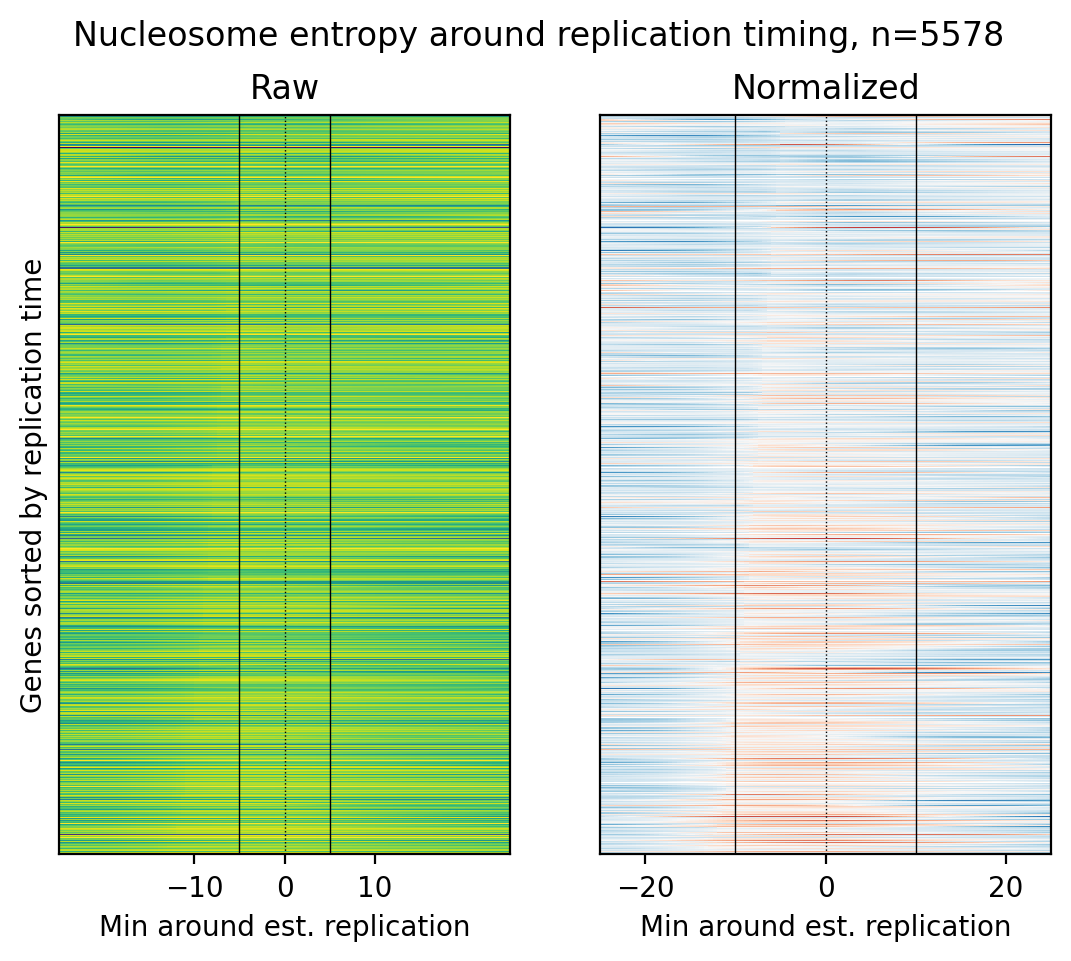

In [465]:
# All genes
_ =plot_raw_and_normalized_entropy(all_gb_entropies_sorted_by_repl, 
    title="Nucleosome entropy")

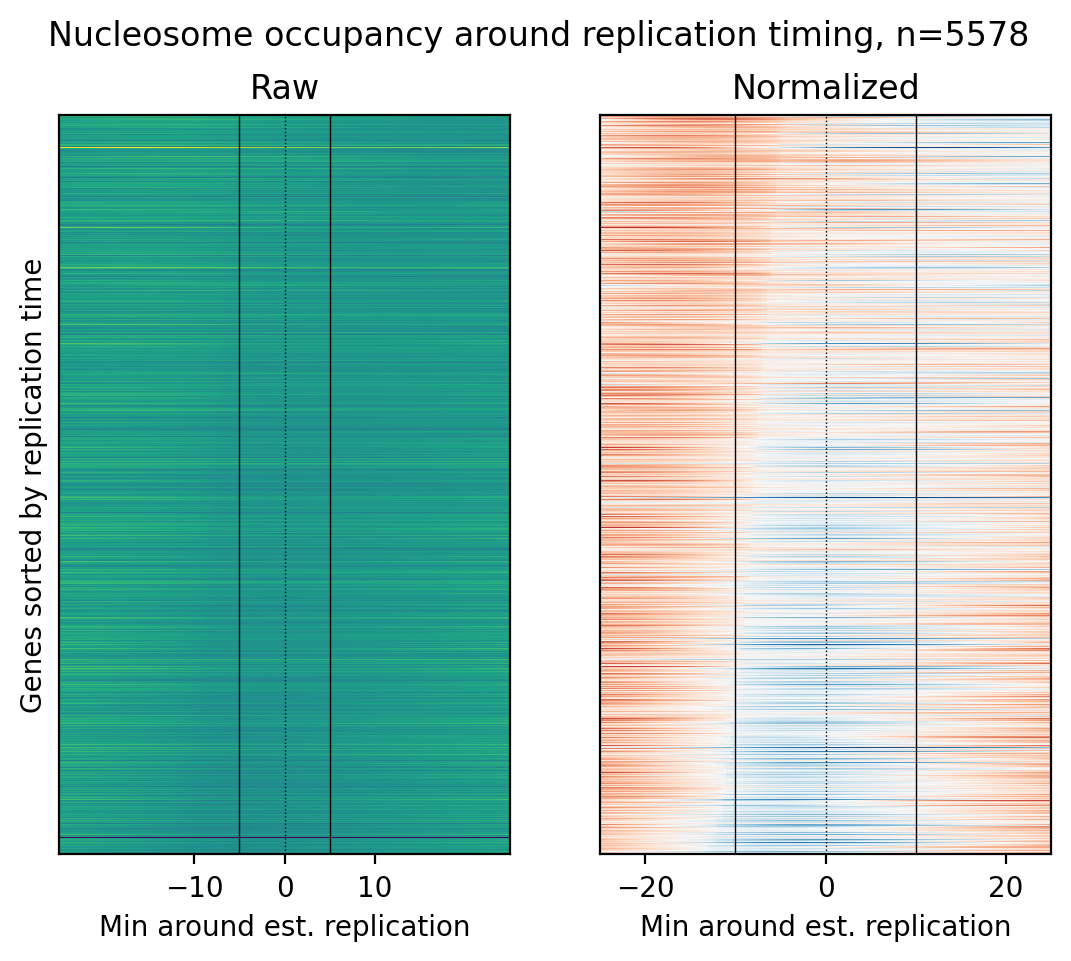

In [464]:
# All genes
_ = plot_raw_and_normalized_entropy(all_gb_occupancies_sorted_by_repl, 
    title="Nucleosome occupancy")

In [15]:
# Load gene expression

from src.gene_clustering import GeneClustering
outdir = 'output/deconvolve_sharedg1_g0066_11x11_2024_08_13/'
gene_clustering = GeneClustering(outdir)


In [299]:
q10 = np.quantile(deconvolved_gene_expression_t.max(axis=1), q=0.1)
q90 = np.quantile(deconvolved_gene_expression_t.max(axis=1), q=0.9)

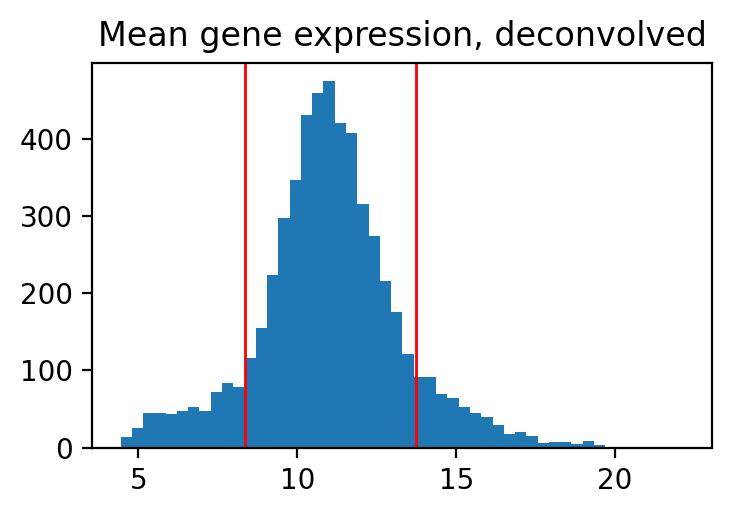

In [300]:
t_indices = gene_clustering.config.get_Hpositions_for_branch('t')
deconvolved_gene_expression_t = gene_clustering.gene_expression[t_indices].loc[all_gb_occ_sorted_by_repl.index]
plt.figure(figsize=(4, 2.5))
plt.hist(deconvolved_gene_expression_t.max(axis=1), bins=50)
plt.title("Mean gene expression, deconvolved")
cutoffs = q10, q90
for cutoff in cutoffs:
    plt.axvline(cutoff, c='red', lw=1)

In [301]:
low_tx_genes = deconvolved_gene_expression_t[
    deconvolved_gene_expression_t.max(axis=1) < cutoffs[0]]

print(f"Low expressed genes: {len(low_tx_genes)}")
print(f"High expressed genes: {len(high_tx_genes)}")

Low expressed genes: 556
High expressed genes: 445


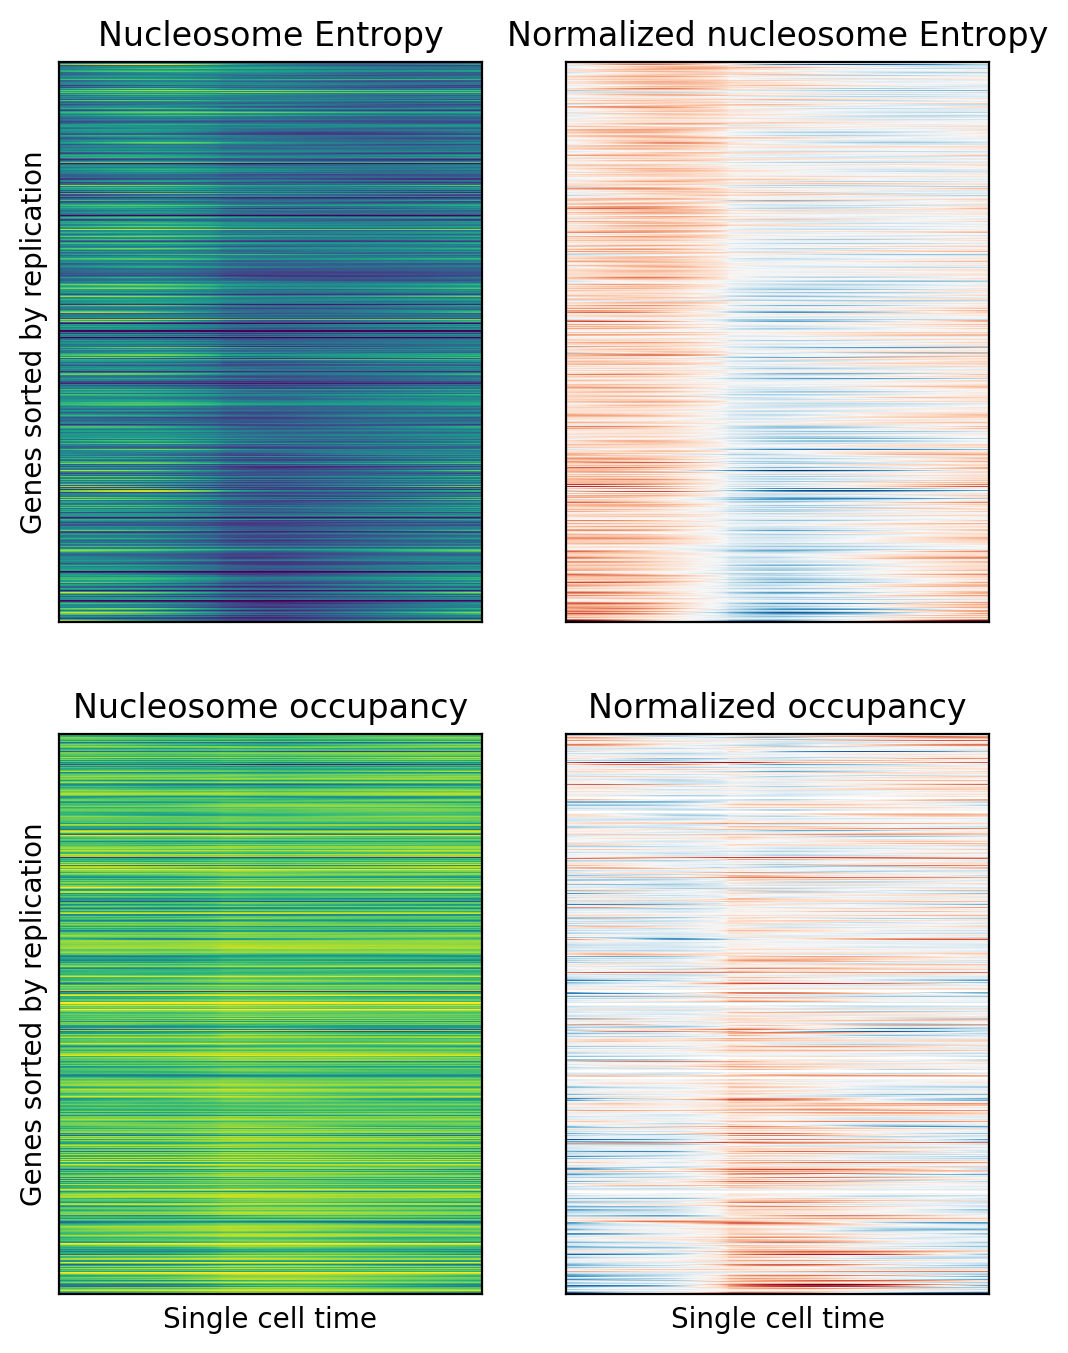

In [347]:
plot_replication_entropy_occupancies(low_tx_occupancies, 
    low_tx_entropies)

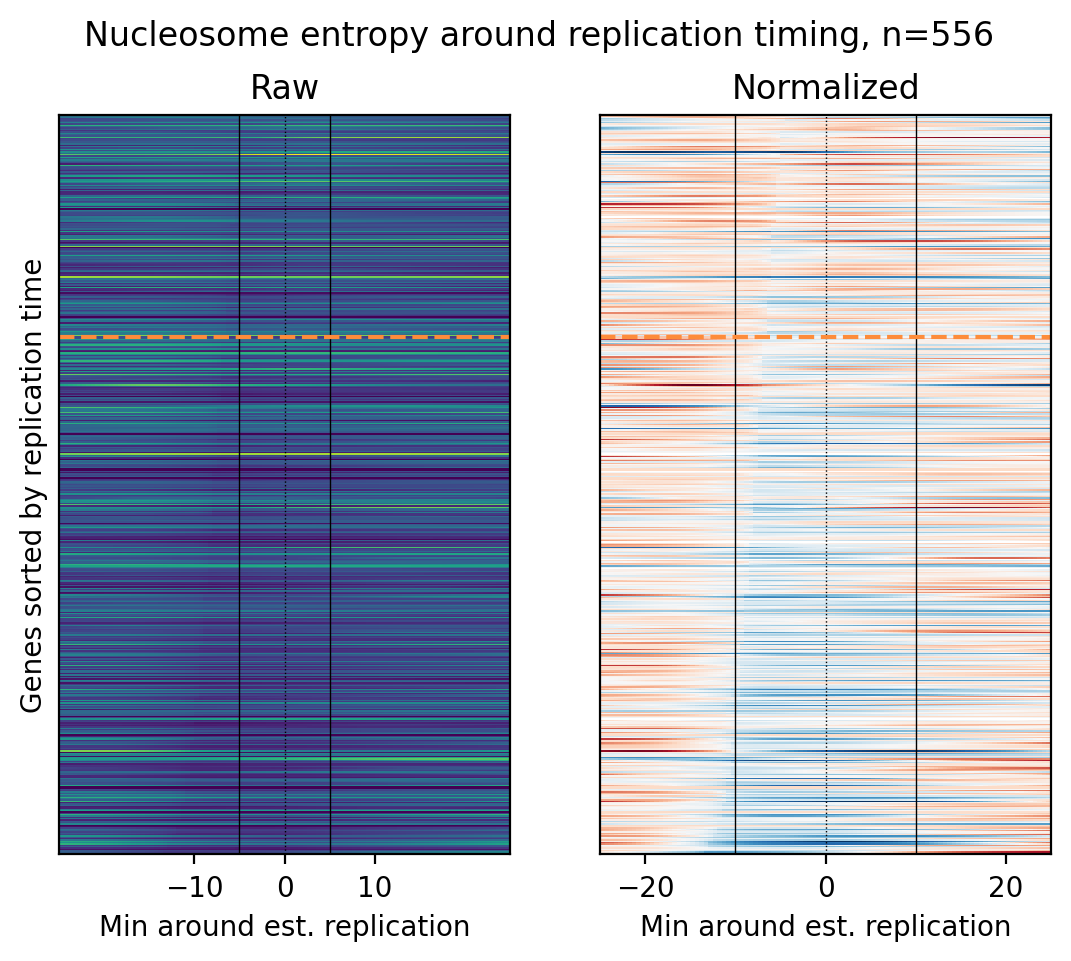

In [516]:
low_tx_entropies = all_gb_entropies_sorted_by_repl.loc[low_tx_genes.index]
low_tx_occupancies = all_gb_occ_sorted_by_repl.loc[low_tx_genes.index]

_ = plot_raw_and_normalized_entropy(-low_tx_entropies, title="Nucleosome entropy",
                                                                       h_line=0.3)

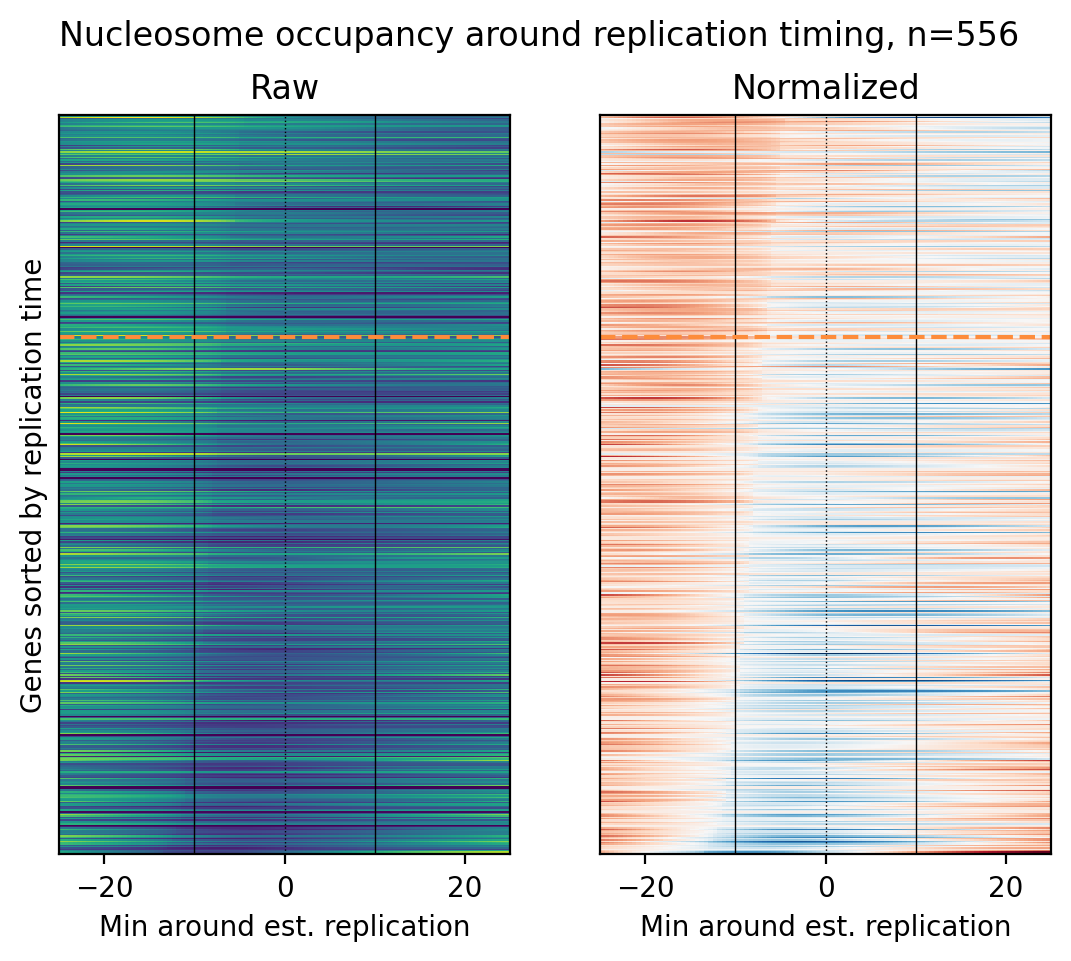

In [360]:
low_tx_entropies = all_gb_entropies_sorted_by_repl.loc[low_tx_genes.index]
low_tx_occupancies = all_gb_occ_sorted_by_repl.loc[low_tx_genes.index]

shifted_normed_occ_data, extent =\
    plot_raw_and_normalized_entropy(low_tx_occupancies, title="Nucleosome occupancy",
                                   h_line=0.3)


In [386]:
n = len(low_tx_occupancies)
earliest_occs = low_tx_occupancies.iloc[:int(n*.3)].index
latest_occs = low_tx_occupancies.iloc[-int(n*.3):].index


In [438]:
from src.chromatin_model import draw_phase_label_annotations
from src.figure_configs import FiguresConfig

high_color = plt.get_cmap('Reds')(0.75)
low_color = plt.get_cmap('Blues')(0.75)

def plot_values_timecourse(values, high_genes, low_genes, title,
                          labels=['Earliest', 'Latest'], ylabel=None, ylim=(0, 2000)):

    t_timepoints = config.get_timepoints_for_branch('t')

    plt.figure(figsize=(6, 4))
    qvals_high = values.loc[high_genes][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)
    qvals_low = values.loc[low_genes][t_indices]\
        .quantile(q=[0.25, 0.5, 0.75], axis=0).dropna().astype(float)

    def plot_qvals(qvals_high, color, label):
        plt.fill_between(t_timepoints, qvals_high.loc[0.25].values, 
                         qvals_high.loc[0.75].values, alpha=0.25, color=color,
                         label=f"{label}, n={len(high_genes)}")
        plt.plot(t_timepoints, qvals_high.loc[0.5], color=color)
    
    plot_qvals(qvals_high, high_color, labels[0])
    plot_qvals(qvals_low, low_color, labels[1])

    plt.suptitle(title,
             fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
    plt.legend()

    
    ax = plt.gca()
    draw_phase_label_annotations(ax, config, flip=True, annotations_x=ylim[0])
    plt.xticks([])
    plt.xlim(t_timepoints[0], t_timepoints[-1])
    plt.subplots_adjust(top=0.82)

    plt.ylabel(ylabel)


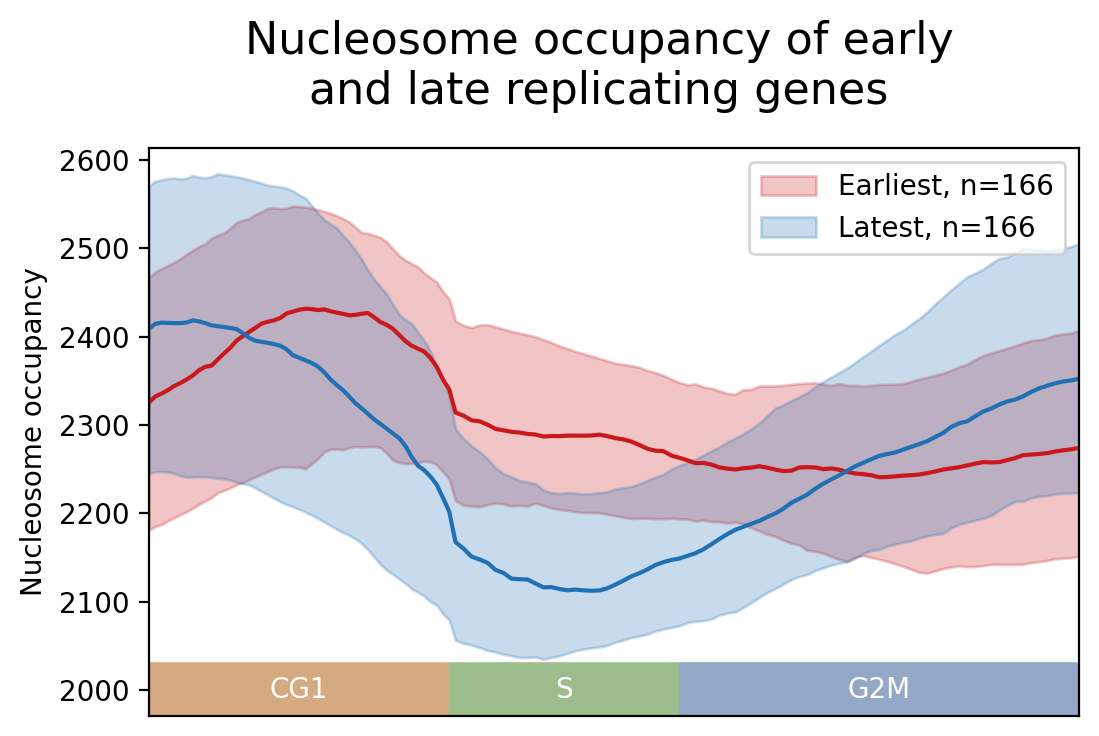

In [439]:
plot_values_timecourse(low_tx_occupancies, earliest_occs, latest_occs, 
    "Nucleosome occupancy of early\nand late replicating genes", 
    ylabel="Nucleosome occupancy", ylim=[2000, 2650])

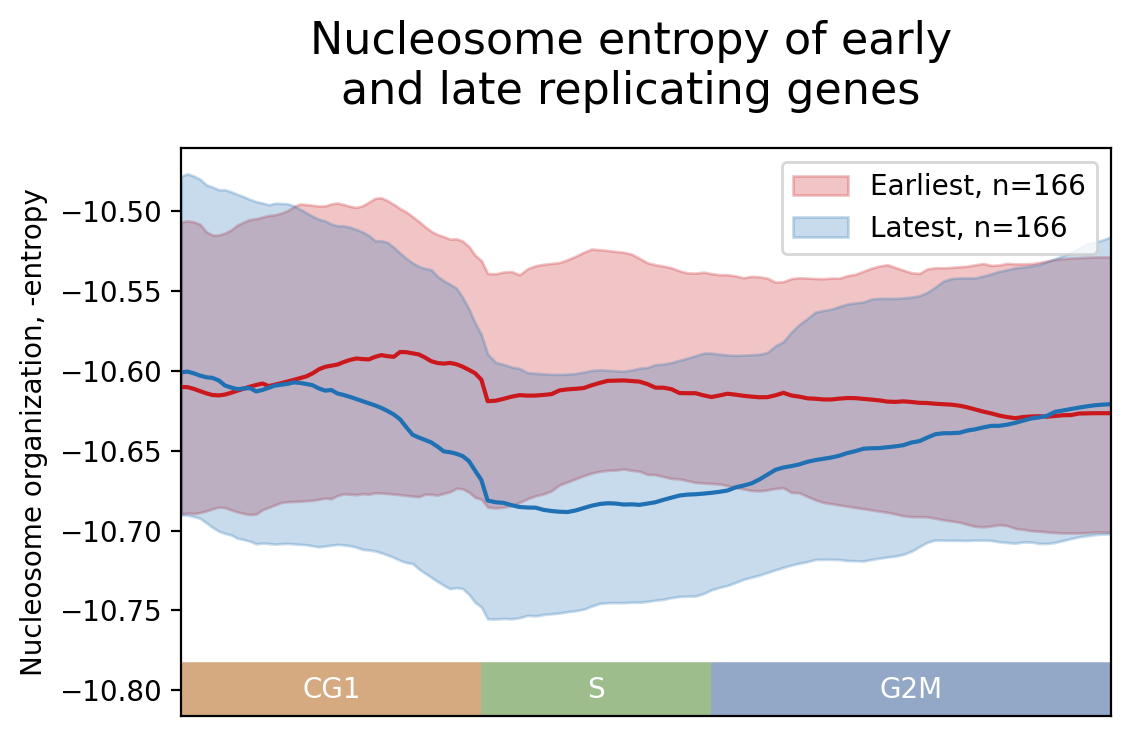

In [526]:
plot_values_timecourse(-low_tx_entropies, earliest_occs, latest_occs, 
    "Nucleosome entropy of early\nand late replicating genes",     
    ylabel="Nucleosome organization, -entropy", ylim=[-10.8, -10.4])

In [442]:
from src.GenomeDeconvolutionAnalysis import plot_tss_pas_chrom

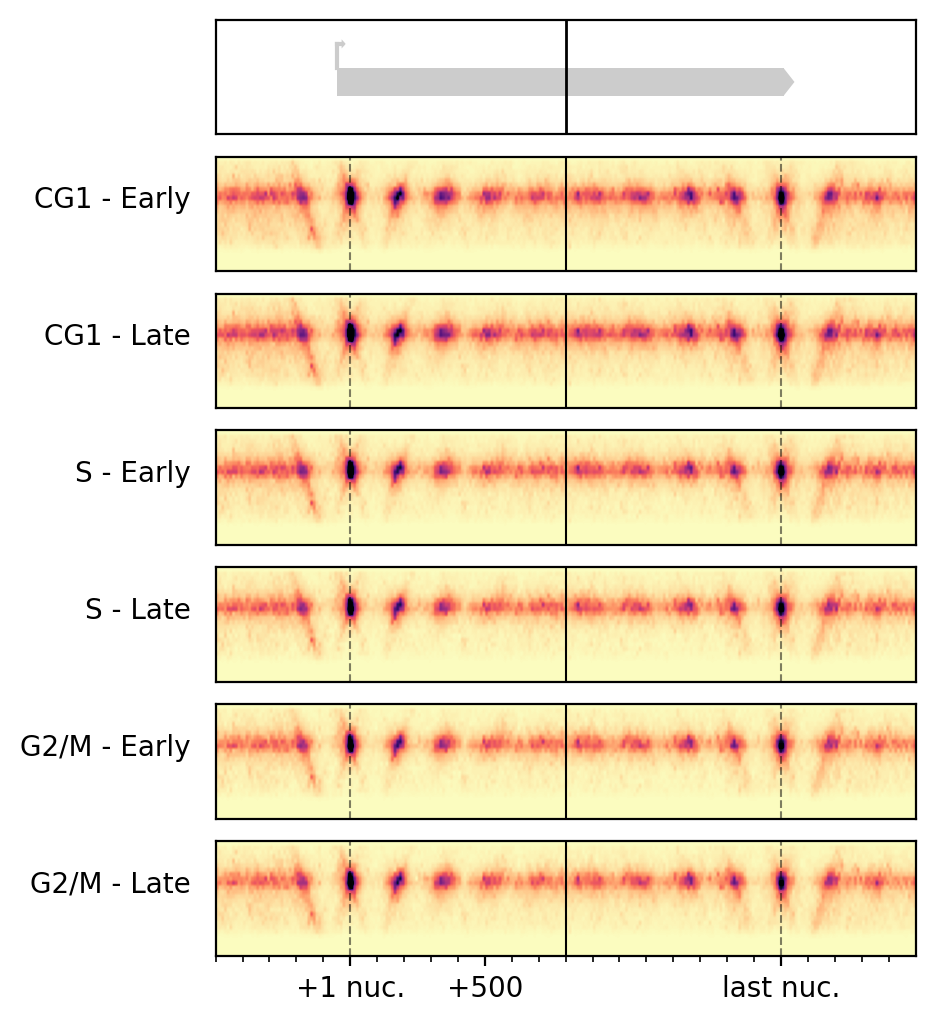

In [452]:
fig = analysis.plot_tss_pas_chrom(low_tx_entropies.loc[earliest_occs])

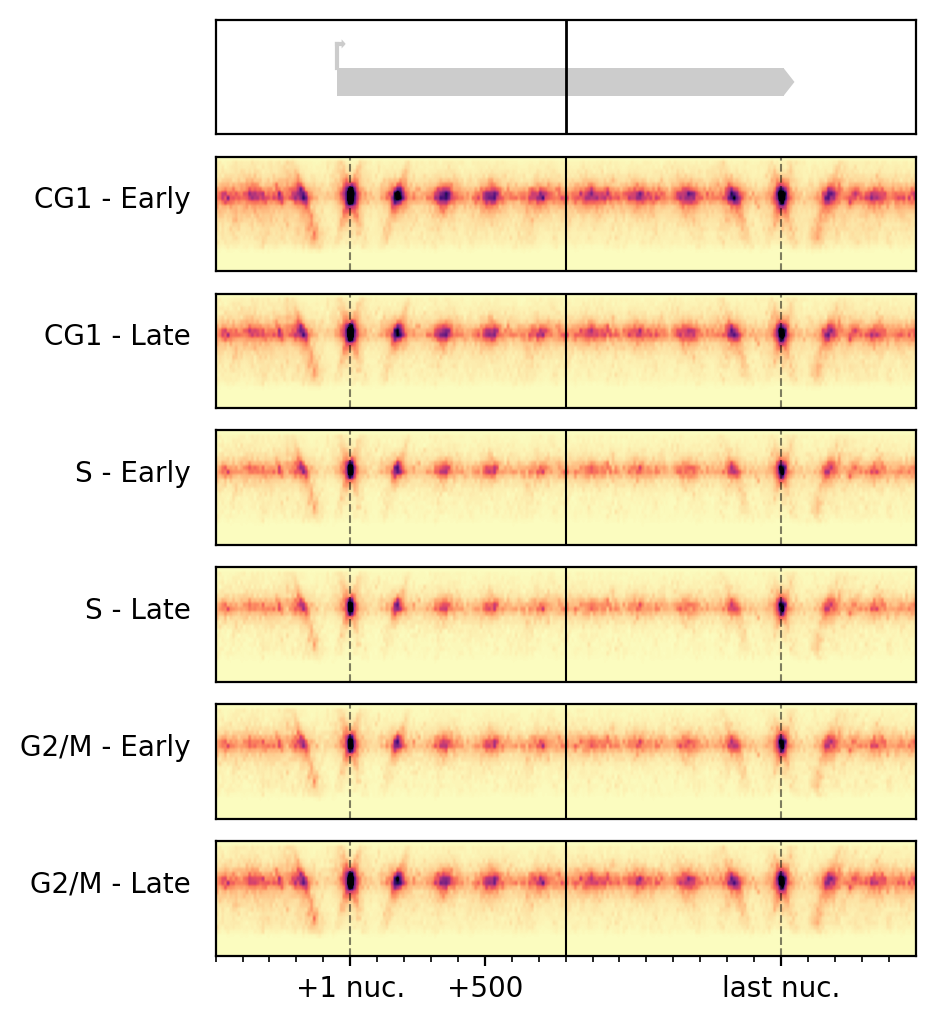

In [453]:
fig = analysis.plot_tss_pas_chrom(low_tx_entropies.loc[latest_occs])

,replication_time,replication_H_index
orf_name,,
YGR194C,4.3477,105.0
YGR195W,4.3477,105.0
YJL116C,4.3477,105.0
YJL115W,4.3477,105.0
YDR046C,4.9289,106.0
...,...,...
YDR252W,15.9710,125.0
YCR086W,17.1333,127.0
YCR087C-A,17.1333,127.0


In [466]:
# Todo convert the h indices to minutes

In [ ]:
raw_window_dat = select_columns_by_indices(all_vals[t_indices], 
    repl_indices_minus, repl_indices_plus)

In [482]:
# Scatter plot of occupancy and entropy levels at replication timing color by replication
# timing, expect to see the differences clearly here

def retrieve_vals_at_replication(cur_vals):
    
    cur_repl_timing = genes_replication.loc[cur_vals.index]
    
    repl_time = cur_repl_timing.replication_H_index.astype(int)
    delta = 10

    cur_vals_at_repl = select_columns_by_indices(cur_vals,
        repl_time-delta, repl_time+delta).mean(axis=1)
    return cur_vals_at_repl, cur_repl_timing


In [485]:
low_tx_entropy_at_rep, cur_repl_timingl = retrieve_vals_at_replication(low_tx_entropies)
low_tx_occ_at_rep, cur_repl_timingl = retrieve_vals_at_replication(low_tx_occupancies)

(28.0, 36.0)

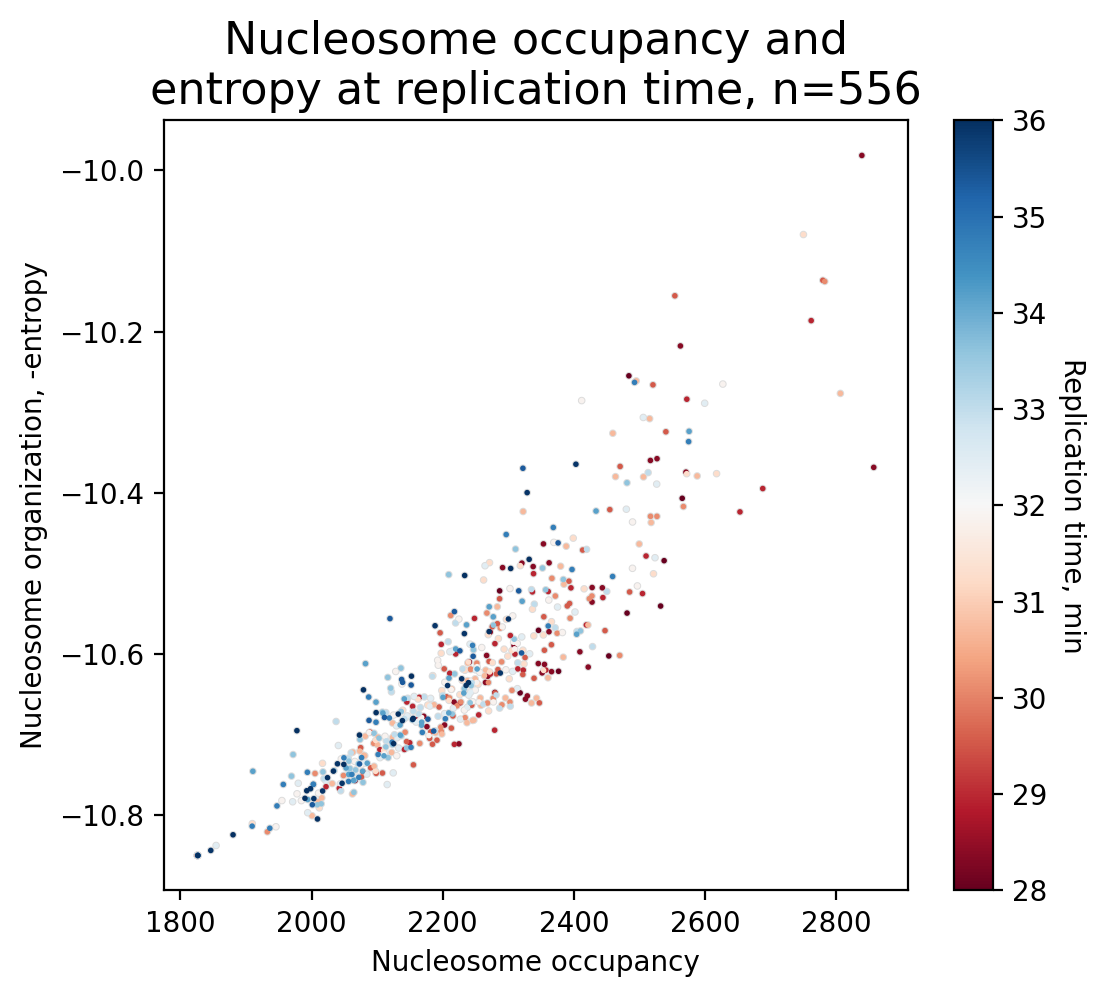

In [543]:
plt.figure(figsize=(6, 5))

cg1_len = config.get_g1_lens('CG1')
cbar_ylim = 28, 36

plt.scatter(low_tx_occ_at_rep, -low_tx_entropy_at_repl, s=3, 
            edgecolor='#dddddd', facecolor='none')
plt.scatter(low_tx_occ_at_rep, -low_tx_entropy_at_repl, s=1, 
            c=cur_repl_timing.replication_time + cg1_len, cmap='RdBu',
            vmin=cbar_ylim[0], vmax=cbar_ylim[1])
plt.title(f"Nucleosome occupancy and\nentropy at replication time, n={len(low_tx_occ_at_rep)}", 
    fontsize=FiguresConfig.FIG_SUPTITLE_FONTSIZE)
plt.ylabel("Nucleosome organization, -entropy")
plt.xlabel("Nucleosome occupancy")
cbar = plt.colorbar()
cbar.ax.set_ylabel("Replication time, min", rotation=270, va='bottom')
cbar.ax.set_ylim(*cbar_ylim)

